## Behavioral Regime ##
This figure corresponds to the code used to generate Figure 4.

In [3]:
import os

save_dir = ######
os.makedirs(save_dir, exist_ok=True)



/var/folders/7q/50zwnmhx4g518srg_9fb7kq80000gn/T/ipykernel_24559/1608598019.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


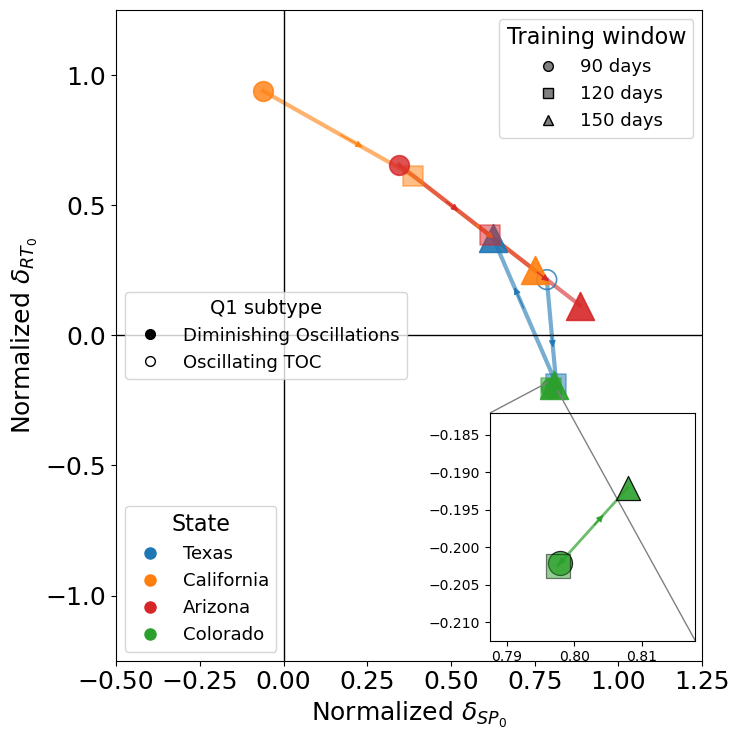

In [79]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ======================
# Normalize
# ======================
def normalize_point(x, y, eps=1e-12):
    scale = abs(x) + abs(y)
    if scale < eps:
        return 0.0, 0.0
    return x / scale, y / scale

# ======================
# Data (SP0, RT0)
# ======================
data = {
    "TX": {
        "90":  {"pt": [1.86940, 0.508984], "regime": "TOC"},
        "120": {"pt": [2.454489, -0.560460], "regime": "DIM"},
        "150": {"pt": [1.197505, 0.716964], "regime": "DIM"},
    },
    "CA": {
        "90":  {"pt": [-0.169461, 2.601267], "regime": "Q2"},
        "120": {"pt": [0.824744, 1.302907], "regime": "DIM"},
        "150": {"pt": [1.145509, 0.382362], "regime": "DIM"},
    },
    "AZ": {
        "90":  {"pt": [0.920449, 1.749527], "regime": "DIM"},
        "120": {"pt": [1.322793, 0.826641], "regime": "DIM"},
        "150": {"pt": [1.825485, 0.235857], "regime": "DIM"},
    },
    "CO": {
        "90":  {"pt": [195.535365, -49.521068], "regime": "Q4"},
        "120": {"pt": [152.526599, -38.71697],  "regime": "Q4"},
        "150": {"pt": [107.163338, -25.47527],  "regime": "Q4"},
    }
}

colors = {
    "TX": "tab:blue",
    "CA": "tab:orange",
    "AZ": "tab:red",
    "CO": "tab:green",
}

markers = {
    "90": "o",
    "120": "s",
    "150": "^",
}

sizes = {
    "90": 200,
    "120": 200,
    "150": 400,
}
alphas = {
    "90": 0.8,
    "120": 0.5,
    "150": 0.9
}

window_order = ["90", "120", "150"]

# ======================
# Normalize data
# ======================
norm_data = {}
for state, windows in data.items():
    norm_data[state] = {}
    for w, info in windows.items():
        x, y = info["pt"]
        xn, yn = normalize_point(x, y)
        norm_data[state][w] = {
            "pt": [xn, yn],
            "regime": info["regime"]
        }

# ======================
# Main figure
# ======================
fig, ax = plt.subplots(figsize=(7.5, 7.5))

for state, windows in norm_data.items():
    xs = [windows[w]["pt"][0] for w in window_order]
    ys = [windows[w]["pt"][1] for w in window_order]

    # trajectory line
    ax.plot(xs, ys, color=colors[state], linewidth=3.0, alpha=0.6)

    # arrows
    for i in range(len(xs) - 1):
        x_mid = (xs[i] + xs[i+1]) / 2
        y_mid = (ys[i] + ys[i+1]) / 2
        dx = xs[i+1] - xs[i]
        dy = ys[i+1] - ys[i]

        scale = 0.18
        ax.annotate(
        '',
        xy=(x_mid + dx * scale, y_mid + dy * scale),   
        xytext=(x_mid, y_mid),                        
        arrowprops=dict(
            arrowstyle='-|>',   
            color=colors[state],
            lw=0.9,
            alpha=0.9,
            mutation_scale=10   #
        )
        )

    # markers
    for w in window_order:
        x, y = windows[w]["pt"]
        regime = windows[w]["regime"]
        facecolor = "none" if regime == "TOC" else colors[state]

        ax.scatter(
            x, y,
            edgecolor=colors[state],
            facecolor=facecolor,
            marker=markers[w],
            s=sizes[w],
            linewidth=1.2,
            alpha=alphas[w],
            zorder=3
        )

# axes
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)


plt.xlim(-0.5, 1.25)
plt.ylim(-1.25, 1.25)

ax.set_xlabel(r'Normalized $\delta_{SP_0}$', fontsize=18)
ax.set_ylabel(r'Normalized $\delta_{RT_0}$', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
# ======================
# Inset (CO zoom)
# ======================
axins = inset_axes(
    ax,
    width="35%",
    height="35%",
    loc='lower right',
    bbox_to_anchor=(0, 0.02, 1, 1),
    bbox_transform=ax.transAxes
)

co = norm_data["CO"]
xs = [co[w]["pt"][0] for w in window_order]
ys = [co[w]["pt"][1] for w in window_order]

# inset trajectory
axins.plot(xs, ys, color="tab:green", linewidth=2.0, alpha=0.7)

# inset arrows
for i in range(len(xs) - 1):
    x_mid = (xs[i] + xs[i+1]) / 2
    y_mid = (ys[i] + ys[i+1]) / 2
    dx = xs[i+1] - xs[i]
    dy = ys[i+1] - ys[i]

    scale = 0.18
    axins.annotate(
        '',
        xy=(x_mid + dx * scale, y_mid + dy * scale),  
        xytext=(x_mid, y_mid),                       
        arrowprops=dict(
            arrowstyle='-|>',   
            color=colors[state],
            lw=0.9,
            alpha=0.9,
            mutation_scale=10   
        )
    )

# inset markers with different shapes
for w in window_order:
    x, y = co[w]["pt"]
    axins.scatter(
        x, y,
        color="tab:green",
        marker=markers[w],
        s= 300,
        edgecolor='black',
        linewidth=0.9,
        alpha=alphas[w],
        zorder=3
    )
    

# zoom range
x_min, x_max = min(xs), max(xs)
y_min, y_max = min(ys), max(ys)
margin = 0.01

axins.set_xlim(x_min - margin, x_max + margin)
axins.set_ylim(y_min - margin, y_max + margin)
axins.tick_params(axis='both', labelsize=10)
#axins.set_title("Colorado (zoom)", fontsize=9)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray")

# ======================
# Legends
# ======================
state_handles = [
    Line2D([0], [0], marker='o', color='w', label='Texas',
           markerfacecolor='tab:blue', markeredgecolor='tab:blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='California',
           markerfacecolor='tab:orange', markeredgecolor='tab:orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Arizona',
           markerfacecolor='tab:red', markeredgecolor='tab:red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Colorado',
           markerfacecolor='tab:green', markeredgecolor='tab:green', markersize=8),
]
legend1 = ax.legend(handles=state_handles, title="State", loc='lower left',fontsize=13,title_fontsize=16)
ax.add_artist(legend1)

window_handles = [
    Line2D([0], [0], marker='o', color='black', label='90 days',
           linestyle='None', markerfacecolor='gray', markersize=7),
    Line2D([0], [0], marker='s', color='black', label='120 days',
           linestyle='None', markerfacecolor='gray', markersize=7),
    Line2D([0], [0], marker='^', color='black', label='150 days',
           linestyle='None', markerfacecolor='gray', markersize=7),
]
legend2 = ax.legend(handles=window_handles, title="Training window", loc='upper right',fontsize=13,title_fontsize=16)
ax.add_artist(legend2)

regime_handles = [
    Line2D([0], [0], marker='o', color='black', label='Diminishing Oscillations',
           markerfacecolor='black', linestyle='None', markersize=7),
    Line2D([0], [0], marker='o', color='black', label='Oscillating TOC',
           markerfacecolor='none', linestyle='None', markersize=7),
]
ax.legend(handles=regime_handles, title="Q1 subtype", loc='center left',fontsize=13,title_fontsize=14)

# ======================
# Save
# ======================
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "behavioral_regimes_with_inset.png"),
            dpi=300, bbox_inches='tight')
plt.show()